In [1]:
days_holding = "30"
top_percentile = "0.9"
bottom_percentile = "0.00"
days_momentum_score = "100"
days_momentum_gate = ""

In [2]:
days_holding_P = int(days_holding)
top_percentile_P = float(top_percentile)
bottom_percentile_P = (
    float(bottom_percentile) if bottom_percentile != "None" else None
)
days_momentum_score_P = int(days_momentum_score)
days_momentum_gate_P = [int(n) for n in days_momentum_gate.split(",") if n != ""]

print(f"""
days_holding: {days_holding_P}
days_momentum_score: {days_momentum_score_P}
days_momentum_gate: {days_momentum_gate_P}

top_percentile: {top_percentile_P}
bottom_percentile: {bottom_percentile_P}
""")


days_holding: 30
days_momentum_score: 100
days_momentum_gate: []

top_percentile: 0.9
bottom_percentile: 0.0



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1224/1224 [00:02<00:00, 569.78it/s]


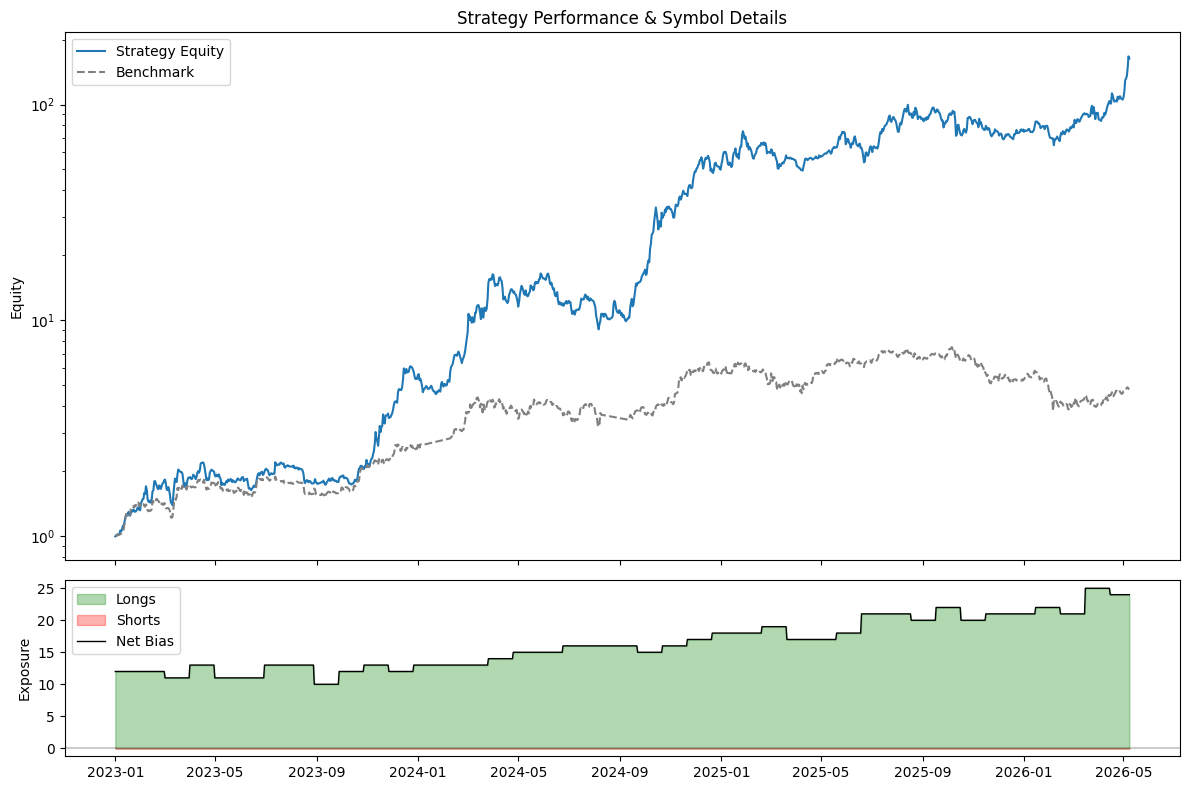

win_rate: 0.6056319213645067 (None)


cagr: 5.327897693957276 (0.582393648182554)


ann_return: 1.2926629241507763 (0.3116568218612308)


mfe: 1.2394497383973546 (None)


sortino: 4.61311720934644 (1.6352461886287082)


...

ann_std: 0.5834496565548632 (0.38786714953305)


mfe_std: 4.2711015919575885 (None)


mae_std: 0.17914715217194077 (None)


sharpe: 2.1807893024006253 (0.8287953512108928)


mae: -0.1998633397940748 (None)


In [3]:
import datetime as dt
import polars as pl
import scrapbook as sb
import backtest as bt
import functools as fc
import operator

df = (
    pl.read_parquet("polarity/latest-data/*parquet")
    .rename(
        {
            "asset": "symbol",
            "price": "close",
        }
    )
    .with_columns(ts=pl.col("ts").dt.cast_time_unit("us"))

    #.join(
    #    pl.read_parquet('stables-1d.parquet')
    #    .with_columns(
    #        ts=pl.col("ts").dt.cast_time_unit("us").dt.replace_time_zone(None),
    #        symbol=pl.col('symbol').str.to_lowercase().str.strip_suffix('usdt'),
    #    ),
    #    on=['ts','symbol'],
    #    how='inner'
    #)
    .sort(["symbol", "ts"])
    .with_columns(**{
        f'mom{n}': pl.col("close").pct_change(n).over("symbol")
        for n in set([days_momentum_score_P, *days_momentum_gate_P])
    })
    .with_columns(
        rank=(
            pl.col(f"mom{days_momentum_score_P}").rank(method="ordinal").over("ts")
            / pl.col(f"mom{days_momentum_score_P}").count().over("ts")
        ),
        volume=pl.col('total_volume').rolling_mean(days_holding_P).over('symbol'),
    )
    .sort("ts")
    .filter(pl.col("ts").dt.year() >= 2023)
    .drop_nulls(['volume'])
)

#print(df)

#df = (
#    df.join(
#        df.filter(pl.col('symbol') == 'btc')
#        .sort(["symbol", "ts"])
#        .select(
#            ts=pl.col('ts'),
##            mkt=(pl.col('close') - pl.col('mdccv')) / pl.col('close'),
#            mktdelta=pl.col('mdccv').diff(5).over('symbol'),
#        ),
#        on='ts',
#        how='inner',
#    )
#)

class Alpha(bt.AlphaModel):
    def __init__(self, long_expr: pl.Expr, short_expr: pl.Expr):
        self.long_expr = long_expr
        self.short_expr = short_expr

    def __call__(self, df: pl.DataFrame) -> list[bt.Signal]:
        today = df["ts"].max()
        dfnow = df.filter(pl.col("ts") == today)
        l = dfnow.filter(self.long_expr)
        s = dfnow.filter(self.short_expr)

        return [
            bt.Signal(r['symbol'], True, r['rank'])
            for r in l.iter_rows(named=True)
        ] + [
            bt.Signal(r['symbol'], False, 1-r['rank'])
            for r in s.iter_rows(named=True)
        ]

if len(days_momentum_gate_P) > 0:
    long_gate_expr = fc.reduce(operator.or_, [pl.col(f'mom{n}') > 0 for n in days_momentum_gate_P]) & (pl.col('mkt') > -0.0)
    short_gate_expr = fc.reduce(operator.and_, [pl.col(f'mom{n}') < 0 for n in days_momentum_gate_P]) & (pl.col('mkt') < -0.15)
else:
    long_gate_expr = pl.lit(True)
    short_gate_expr = pl.lit(True)


test = bt.Backtest(
    df,
    alpha=Alpha(
        long_expr=(pl.col("rank") >= top_percentile_P) & long_gate_expr & (pl.col('volume') > 100_000),
        short_expr=(
            (pl.col("rank") <= bottom_percentile_P) & short_gate_expr & (pl.col('volume') > 100_000)
            if bottom_percentile_P is not None
            else pl.lit(False)
        ),
    ),
    #portfolio=bt.VolumeWeighted(),
    #risk=bt.MaxDrawdown(.3, .3),
    benchmark="btc",
    period=days_holding_P,
    eager_rebalance=True,
)

test.run()
res = test.report(plot=True)

for col in set(res.columns) - {'year', 'src'}:
    s = res.filter(pl.col('src') == 'Strategy')
    b = res.filter(pl.col('src') == 'Benchmark')

    print(f"{col}: {s[col].mean()} ({b[col].mean()})")
    sb.glue(col,s[col].mean())